# ModelBuilding and Training

In [1]:
#auto reloading enabled
%load_ext autoreload
%autoreload 2

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.preprocessing import FeatureEngineerTransform, DataFrameLabelEncoder, scale_features, evaluate
from src.constants import NUMERICAL_COLS, CATEGORICAL_COLS, TARGET_COL, COLUMN_NAMES


from src.model_training import prepare_and_split_data, optimize_threshold, evaluate_with_cv, plot_feature_importance, shap_explainability

SEED =42

In [3]:
credit_df = pd.read_csv('../data/raw/creditcard.csv')
credit_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
fraud_df = pd.read_csv("../data/processed/fraud_mapped.csv")
fraud_df.head(3)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,country,signup_to_purchase_time,immediate_purchase,device_sharing_count,ip_sharing_count
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,732758368,Japan,4506682.0,0,1,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,350311387,United States,17944.0,0,1,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,2621473820,United States,1.0,1,12,12


## Train-Test Split

In [5]:
X_fraud_temp, X_fraud_test, y_fraud_temp, y_fraud_test = prepare_and_split_data(
    df=fraud_df, 
    target_column='class'
)

# 3. Verify it worked by inspecting the unpacked variables
print("\nSuccessfully loaded variables into the notebook context:")
print(f"Fraud Features training set sample dimension: {X_fraud_temp.shape}")


--- Distribution Summary for Target: 'class' ---
Train Shape: (120889, 16) | Test Shape: (30223, 16)
Train class ratios:
 {0: 0.9063521081322535, 1: 0.09364789186774644}
Test class ratios:
 {0: 0.9063627039010026, 1: 0.09363729609899746}

Successfully loaded variables into the notebook context:
Fraud Features training set sample dimension: (120889, 16)


In [6]:
# Second split: Separate remaining data into Train (75% of temp -> 60% total) and Validation (25% of temp -> 20% total)
from sklearn.model_selection import train_test_split


x_fraud_train, x_fraud_val, y_fraud_train, y_fraud_val = train_test_split(
    X_fraud_temp, y_fraud_temp, test_size=0.25, random_state=42, stratify=y_fraud_temp
)

print(f"Train size: {x_fraud_train.shape[0]} | Val size: {x_fraud_val.shape[0]} | Test size: {X_fraud_test.shape[0]}")

Train size: 90666 | Val size: 30223 | Test size: 30223


In [8]:
X_credit_temp, X_credit_test, y_credit_temp, y_credit_test = prepare_and_split_data(
    df=credit_df, 
    target_column='Class'
)

# 3. Verify it worked by inspecting the unpacked variables
print("\nSuccessfully loaded variables into the notebook context:")
print(f"Credit Features training set sample dimension: {X_credit_temp.shape}")


--- Distribution Summary for Target: 'Class' ---
Train Shape: (227845, 30) | Test Shape: (56962, 30)
Train class ratios:
 {0: 0.9982707542408216, 1: 0.001729245759178389}
Test class ratios:
 {0: 0.9982795547909132, 1: 0.0017204452090867595}

Successfully loaded variables into the notebook context:
Credit Features training set sample dimension: (227845, 30)


In [9]:
# Second split: Separate remaining data into Train (75% of temp -> 60% total) and Validation (25% of temp -> 20% total)

x_credit_train, x_credit_val, y_credit_train, y_credit_val = train_test_split(
    X_credit_temp, y_credit_temp, test_size=0.25, random_state=42, stratify=y_credit_temp
)

print(f"Train size: {x_credit_train.shape[0]} | Val size: {x_credit_val.shape[0]} | Test size: {X_credit_test.shape[0]}")

Train size: 170883 | Val size: 56962 | Test size: 56962


## Feature Scaling

In [10]:
# Initialize a fresh scaler instance for each distinct dataset
scaler_fraud = StandardScaler()

scaler_credit = StandardScaler()

In [31]:
columns_to_drop = ['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country', 'user_id']

# Isolate the final list of numeric columns we ACTUALLY want to scale and use
numeric_cols_fraud = [
    col for col in x_fraud_train.columns 
    if pd.api.types.is_numeric_dtype(x_fraud_train[col]) and col not in columns_to_drop
]

# Create clean, scaled dataframes keeping only the features we care about
X_fraud_train_scaled = pd.DataFrame(
    scaler_fraud.fit_transform(x_fraud_train[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=x_fraud_train.index
)

# ONLY transform the test data using the exact same columns
X_fraud_test_scaled = pd.DataFrame(
    scaler_fraud.transform(X_fraud_test[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=X_fraud_test.index
)

X_fraud_val_scaled = pd.DataFrame(
    scaler_fraud.transform(x_fraud_val[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=x_fraud_val.index
)

# 2. SCALING CREDIT CARD DATA 
numeric_cols_credit = x_credit_train.select_dtypes(include=['number']).columns
print(numeric_cols_credit)

X_credit_train_scaled = x_credit_train.copy()
X_credit_train_scaled[numeric_cols_credit] = scaler_credit.fit_transform(x_credit_train[numeric_cols_credit])

X_credit_test_scaled = X_credit_test.copy()
X_credit_test_scaled[numeric_cols_credit] = scaler_credit.transform(X_credit_test[numeric_cols_credit])

# === ADD THIS LINE: Scale the validation data too! ===
X_credit_val_scaled = x_credit_val.copy()
X_credit_val_scaled[numeric_cols_credit] = scaler_credit.transform(x_credit_val[numeric_cols_credit])
print(X_credit_train_scaled)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')
            Time        V1        V2        V3        V4        V5        V6  \
74456  -0.827530  0.569452  0.154778  0.160294  0.772850 -0.021699 -0.343261   
96407  -0.613366 -0.535284  0.852866 -0.672467 -0.773766  1.565807  2.823225   
198242  0.790770  0.081269 -2.282126 -2.326968  0.300534 -0.660797 -0.871808   
27489  -1.270458  0.719337 -0.751048  0.527785 -0.903203 -1.425724 -0.626310   
121114 -0.395895 -0.082972  0.427990  1.098193  0.665746  0.239225 -0.058739   
...          ...       ...       ...       ...       ...       ...       ...   
24156  -1.301601  0.007404  0.508069  0.929391  1.202196 -0.452295  0.199676   
258612  1.345774 -1.728358  1.975248 -1.476112  0.701979 -0.534571  0.719467   
19453  -1.360515 -0.887142 -0.5425

## Linear Regression by SMOTE

Before SMOTE: {0: np.int64(82175), 1: np.int64(8491)}
After SMOTE:  {0: np.int64(82175), 1: np.int64(41087)}
Created 32596 SYNTHETIC Default loans
These are new, unique loans — not copies of existing ones

=== SMOTE ===  (best threshold: 0.91)
  Recall    : 54.56%  ← % of real defaults caught
  Precision : 98.28%  ← % of alerts that are real
  F1-Score  : 0.7017
  AUC-PR    : 0.6984  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8446


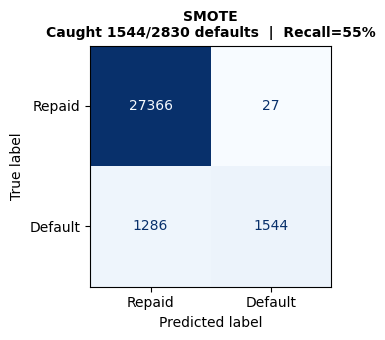

In [47]:
smote = SMOTE(
    sampling_strategy=0.5,  # same target ratio as oversampling
    k_neighbors=5,          # how many nearest neighbours to interpolate between
    random_state=SEED
)
x_fraud_smote, y_fraud_smote = smote.fit_resample(X_fraud_train_scaled, y_fraud_train)

print('Before SMOTE:', dict(pd.Series(y_fraud_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_fraud_smote).value_counts()))
print(f'Created {y_fraud_smote.sum() - y_fraud_train.sum()} SYNTHETIC Default loans')
print('These are new, unique loans — not copies of existing ones')

lr_fraud = LogisticRegression(random_state=SEED, max_iter=1000)
lr_fraud.fit(x_fraud_smote, y_fraud_smote)

fraud_result_smote = evaluate('SMOTE', lr_fraud, X_fraud_val_scaled, y_fraud_val)


Before SMOTE: {0: np.int64(170588), 1: np.int64(295)}
After SMOTE:  {0: np.int64(170588), 1: np.int64(85294)}
Created 84999 SYNTHETIC Default loans
These are new, unique loans — not copies of existing ones

=== Balanced LR ===  (best threshold: 1.00)
  Recall    : 71.72%  ← % of real defaults caught
  Precision : 82.56%  ← % of alerts that are real
  F1-Score  : 0.7676
  AUC-PR    : 0.6807  ← primary metric (threshold-independent)
  AUC-ROC   : 0.9747


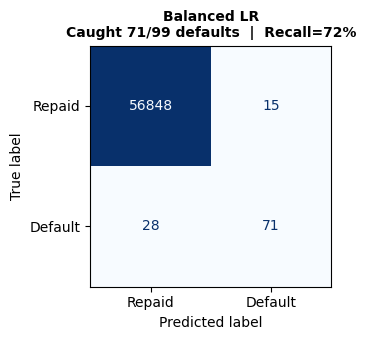

In [48]:
smote = SMOTE(
    sampling_strategy=0.5,  # same target ratio as oversampling
    k_neighbors=5,          # how many nearest neighbours to interpolate between
    random_state=SEED
)
x_credit_smote, y_credit_smote = smote.fit_resample(X_credit_train_scaled, y_credit_train)

print('Before SMOTE:', dict(pd.Series(y_credit_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_credit_smote).value_counts()))
print(f'Created {y_credit_smote.sum() - y_credit_train.sum()} SYNTHETIC Default loans')
print('These are new, unique loans — not copies of existing ones')

# Drop SMOTE entirely for this test and let the loss function handle weights
lr_credit_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

# Initialize and fit the model using class weights
lr_credit_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

# Train on the clean, scaled training data
lr_credit_balanced.fit(X_credit_train_scaled, y_credit_train)

# === FIX THIS: Evaluate using X_credit_val_scaled instead of x_credit_val ===
credit_result = evaluate('Balanced LR', lr_credit_balanced, X_credit_val_scaled, y_credit_val)

## Ensemble Models

In [66]:
# empty pipelines to hold results
fraud_pipeline_runs = {}
credit_pipeline_runs = {}

In [81]:
xgb_fraud =  XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, scale_pos_weight=10)
fraud_pipeline_runs["XGBoost (Base)"] = evaluate_with_cv("XGBoost (Base)", xgb_fraud, X_fraud_train_scaled, y_fraud_train)

   -> Fold 1 | F1: 0.6966 | Precision: 1.0000 | Recall: 0.5344
   -> Fold 2 | F1: 0.7033 | Precision: 1.0000 | Recall: 0.5424
   -> Fold 3 | F1: 0.7107 | Precision: 1.0000 | Recall: 0.5512
   -> Fold 4 | F1: 0.7050 | Precision: 0.9968 | Recall: 0.5453
   -> Fold 5 | F1: 0.6888 | Precision: 1.0000 | Recall: 0.5253
✓ XGBoost (Base) 5-Fold CV Completed. Mean F1: 0.7009


In [82]:
xgb_fraud_smote =  XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, scale_pos_weight=10)

fraud_pipeline_runs["XGBoost (SMOTE)"] = evaluate_with_cv("XGBoost (SMOTE)", xgb_fraud_smote, x_fraud_smote, y_fraud_smote)

   -> Fold 1 | F1: 0.8267 | Precision: 0.8503 | Recall: 0.8043
   -> Fold 2 | F1: 0.8344 | Precision: 0.8561 | Recall: 0.8138
   -> Fold 3 | F1: 0.8406 | Precision: 0.8556 | Recall: 0.8261
   -> Fold 4 | F1: 0.8280 | Precision: 0.8523 | Recall: 0.8050
   -> Fold 5 | F1: 0.8372 | Precision: 0.8522 | Recall: 0.8228
✓ XGBoost (SMOTE) 5-Fold CV Completed. Mean F1: 0.8334


In [83]:
df_fraud_results = pd.DataFrame(fraud_pipeline_runs).T

In [84]:
xgb_credit =  XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, scale_pos_weight=10)
credit_pipeline_runs["XGBoost (Base)"] = evaluate_with_cv("XGBoost (Base)", xgb_credit, X_credit_train_scaled, y_credit_train)

   -> Fold 1 | F1: 0.7708 | Precision: 1.0000 | Recall: 0.6271
   -> Fold 2 | F1: 0.8909 | Precision: 0.9608 | Recall: 0.8305
   -> Fold 3 | F1: 0.8947 | Precision: 0.9273 | Recall: 0.8644
   -> Fold 4 | F1: 0.9298 | Precision: 0.9636 | Recall: 0.8983
   -> Fold 5 | F1: 0.8113 | Precision: 0.9149 | Recall: 0.7288
✓ XGBoost (Base) 5-Fold CV Completed. Mean F1: 0.8595


In [85]:
xgb_credit_smote =  XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, scale_pos_weight=10)

credit_pipeline_runs["XGBoost (SMOTE)"] = evaluate_with_cv("XGBoost (SMOTE)", xgb_credit_smote, x_credit_smote, y_credit_smote)

   -> Fold 1 | F1: 0.9930 | Precision: 0.9899 | Recall: 0.9962
   -> Fold 2 | F1: 0.9938 | Precision: 0.9896 | Recall: 0.9981
   -> Fold 3 | F1: 0.9936 | Precision: 0.9906 | Recall: 0.9966
   -> Fold 4 | F1: 0.9943 | Precision: 0.9928 | Recall: 0.9958
   -> Fold 5 | F1: 0.9946 | Precision: 0.9923 | Recall: 0.9969
✓ XGBoost (SMOTE) 5-Fold CV Completed. Mean F1: 0.9939


In [86]:
df_credit_results = pd.DataFrame(credit_pipeline_runs).T


In [89]:
def format_results_table(df_results):
    formatted = pd.DataFrame()
    for metric in ['F1', 'Precision', 'Recall', 'ROC-AUC', 'PR-AUC']:
        formatted[metric] = df_results.apply(
            lambda row: f"{row[f'{metric}_mean']:.4f} (±{row[f'{metric}_std']:.4f})", axis=1
        )
    return formatted

print("=== FINAL FRAUD DATASET CROSS-VALIDATION SUMMARY ===")
display(format_results_table(df_fraud_results))

print("\n=== FINAL CREDIT CARD DATASET CROSS-VALIDATION SUMMARY  ===")
display(format_results_table(df_credit_results))

=== FINAL FRAUD DATASET CROSS-VALIDATION SUMMARY ===


,F1,Precision,Recall,ROC-AUC,PR-AUC
XGBoost (Base),0.7009 (±0.0075),0.9994 (±0.0013),0.5397 (±0.0090),0.8431 (±0.0042),0.7160 (±0.0054)
XGBoost (SMOTE),0.8334 (±0.0053),0.8533 (±0.0022),0.8144 (±0.0089),0.9158 (±0.0044),0.9047 (±0.0043)



=== FINAL CREDIT CARD DATASET CROSS-VALIDATION SUMMARY  ===


,F1,Precision,Recall,ROC-AUC,PR-AUC
XGBoost (Base),0.8595 (±0.0589),0.9533 (±0.0300),0.7898 (±0.0992),0.9824 (±0.0160),0.8454 (±0.0835)
XGBoost (SMOTE),0.9939 (±0.0005),0.9910 (±0.0013),0.9967 (±0.0008),0.9998 (±0.0000),0.9995 (±0.0001)


## MOdel Comparison

AS shown above, we have selected Linear Regressor as baseline model and XGBoost as Ensemble model.

    -   When we compare both models based on metrices with and without SMOTE sampling, on both datasets models trained with SMOTE has higher score.

    -   When we compare LR with SMOTE and XGBoost with SMOTE, for both datasets XGBOOST outperforms the LR model with better metrics.



## Feature Importance Analysis


In [39]:
fraud_feature_names = X_fraud_test_scaled.columns.tolist()
print(fraud_feature_names)

['purchase_value', 'age', 'ip_address', 'ip_int', 'signup_to_purchase_time', 'immediate_purchase', 'device_sharing_count', 'ip_sharing_count']


In [61]:
fraud_importance = plot_feature_importance(xgb_fraud_smote, fraud_feature_names)
print(fraud_importance)

device_sharing_count       0.691451
immediate_purchase         0.209677
age                        0.039356
purchase_value             0.025743
signup_to_purchase_time    0.012511
ip_sharing_count           0.012121
ip_address                 0.009141
ip_int                     0.000000
dtype: float32


==============================FRAUD XGB MODEL SHAP ANALYSIS==============================


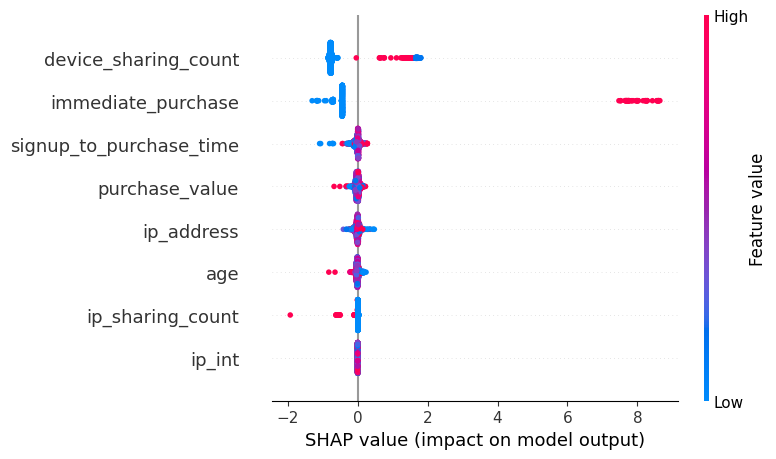

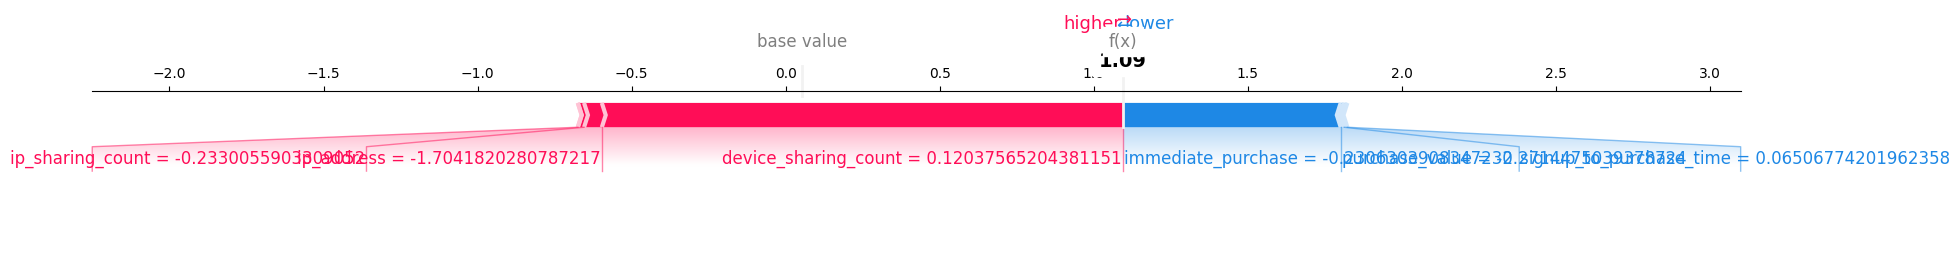

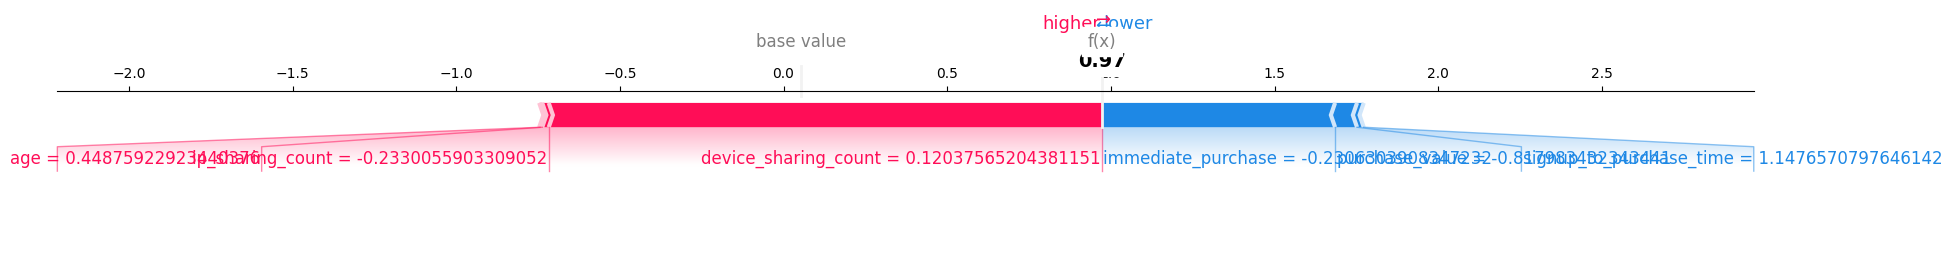

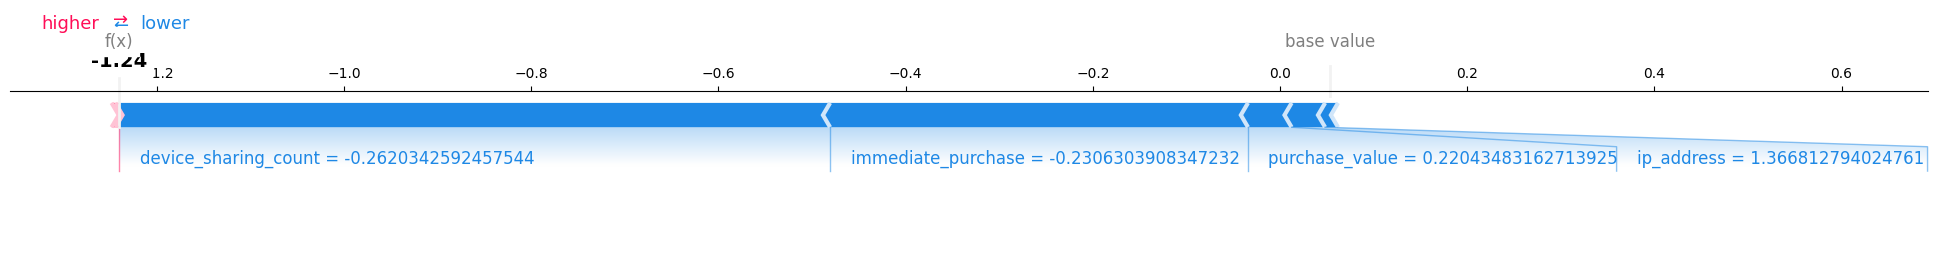

In [64]:
fraud_shap_dir = '../models/shap_fraud'
print('='*30 + 'FRAUD XGB MODEL SHAP ANALYSIS' + '='*30)
credit_shap= shap_explainability(xgb_fraud, X_fraud_test_scaled, y_fraud_test.reset_index(drop=True), fraud_feature_names, fraud_shap_dir)

In [32]:
credit_feature_names = X_credit_test_scaled.columns.tolist()
print(credit_feature_names)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [62]:
credit_importance = plot_feature_importance(xgb_credit_smote, credit_feature_names)
print(credit_importance)

V14    0.375553
V4     0.067131
V8     0.056911
V10    0.052569
V12    0.038360
V1     0.031378
V13    0.029891
V5     0.027552
V18    0.026074
V19    0.022696
dtype: float32


==============================CREDIT XGB MODEL SHAP ANALYSIS==============================


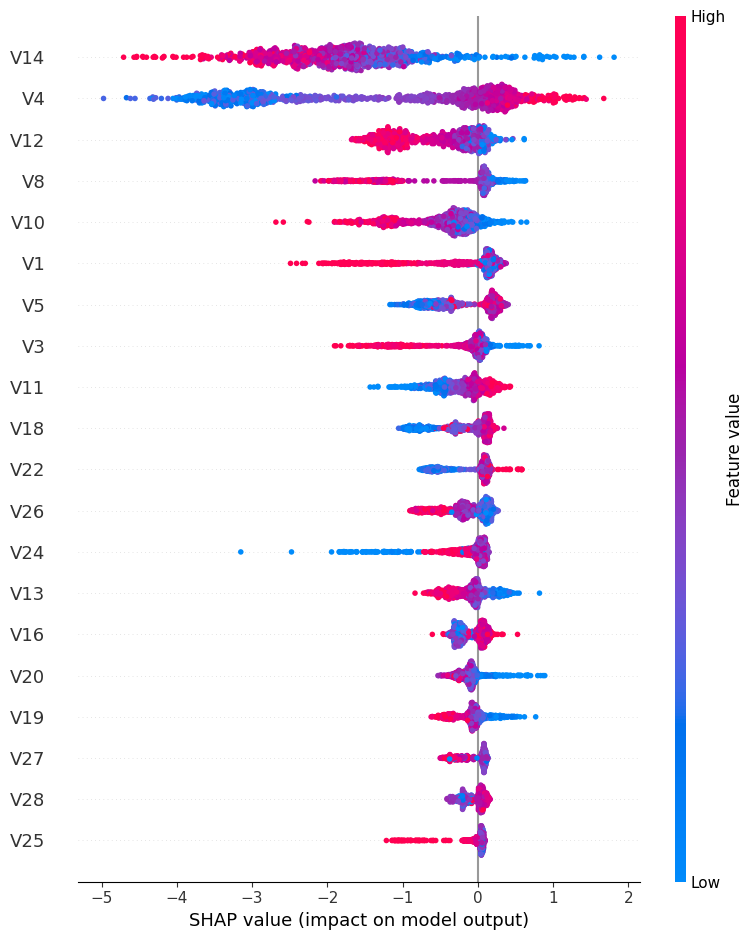

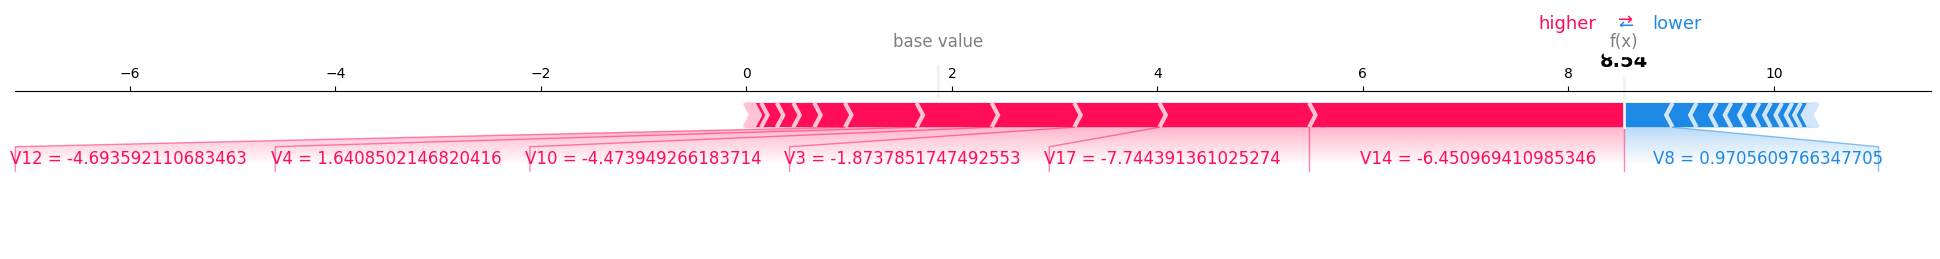

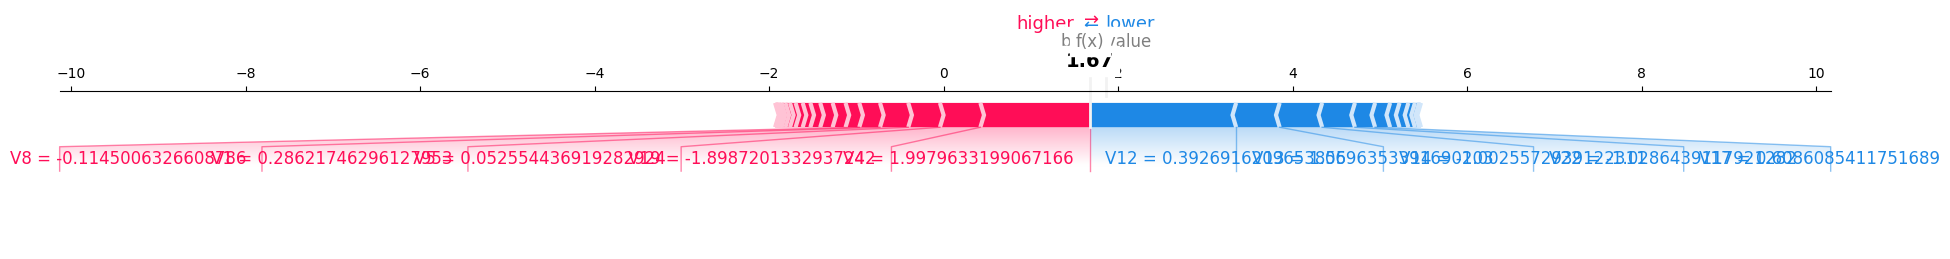

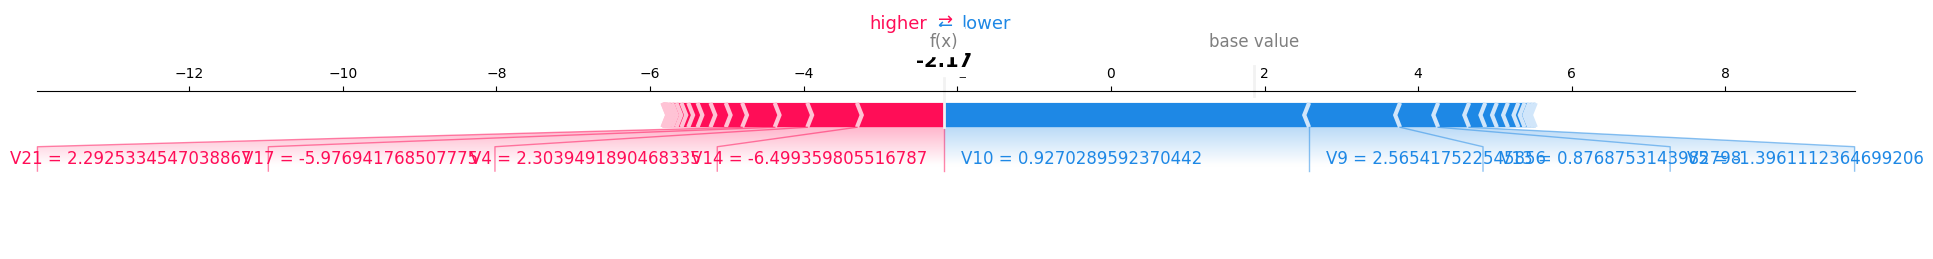

In [63]:
credit_shap_dir = '../models/shap_credit'
print('='*30 + 'CREDIT XGB MODEL SHAP ANALYSIS' + '='*30)
credit_shap= shap_explainability(xgb_credit_smote, X_credit_test_scaled, y_credit_test.reset_index(drop=True), credit_feature_names, credit_shap_dir)

In [44]:
import joblib
joblib.dump(xgb_credit, '../models/best_credit_xgb.joblib')
print('Saved FraudData ensemble model artifact.')
joblib.dump(xgb_fraud, '../models/best_fraud_xgb.joblib')
print('Saved FraudData ensemble model artifact.')

Saved FraudData ensemble model artifact.
Saved FraudData ensemble model artifact.
